<a href="https://colab.research.google.com/github/Rogire/Aulas-MAC019/blob/main/Atividade02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Alunos:
- Igor Correa Trifilio Campos - 202365092AB
- Davi Luís de Faria Rocha - 202365519B


## Instalação de dependências

In [ ]:
# instalação do anastruct
!pip install anastruct

# importando os pacotes
import numpy as np
import matplotlib.pyplot as plt
from anastruct import SystemElements
from collections import defaultdict
from dataclasses import dataclass, field
import pandas as pd
from typing import List, Dict, Optional, Tuple, Any

## Classe para facilitar a manipulação do anastruct: Componentes auxiliares


In [ ]:
@dataclass
class point_load:
    node: str
    load_vec: Tuple[float, float, float]
    rotation: float = 0.0
    node_id_cache: Optional[int] = None

    def load(self, ss: SystemElements, node_id: Optional[int] = None):
        nid = node_id if node_id is not None else self.node_id_cache
        if nid is None:
            raise ValueError("node_id não fornecido para PointLoad.apply")

        return ss.point_load(node_id=nid, Fx=self.load_vec[0], Fy=self.load_vec[1], Fz=self.load_vec[2], rotation=self.rotation)

@dataclass
class charge_load:
    q: float
    element_id: int
    direction: str

    def load(self, ss: SystemElements):
        return ss.q_load(q=self.q, element_id=self.element_id, direction=self.direction)

@dataclass
class node:
    pos: List[float]
    conecs: List[Dict[str, Any]] = field(default_factory=list)
    support: str = ""
    ss_id: Optional[int] = None

    def get_pos(self) -> List[float]:
        return self.pos

    def get_conecs(self) -> List[Dict[str, Any]]:
        return self.conecs

    def get_support_type(self) -> str:
        return self.support
    def id(self, ss: SystemElements) -> int:
        nid = ss.find_node_id(self.pos)
        if nid is None:
            for node_idx, n_obj in ss.node_map.items():
                if np.allclose(n_obj.post, self.pos, atol=1e-3):
                    return node_idx
        return nid

    def get_support(self, ss: SystemElements):
        if not self.support:
            return

        nid = self.id(ss)
        if nid is None: return

        if self.support == "1x":
            ss.add_support_roll(nid, direction="y")
        elif self.support == "1y":
            ss.add_support_roll(nid, direction="x")
        elif self.support == "2":
            ss.add_support_hinged(nid)
        elif self.support == "3":
            ss.add_support_fixed(nid)

class Aux:
    @staticmethod
    def leitura_data(sheet:str, link: bool = True):

        def get_sheet(sheet:str, data_name : str, link:bool = True):
          static_url = "https://docs.google.com/spreadsheets/d/"
          end_share_link = "/edit?usp=sharing"
          id = sheet[len(static_url):-len(end_share_link)]
          download_csv_section = f"/gviz/tq?tqx=out:csv&sheet={data_name}"
          return f"{static_url}{id}{download_csv_section}" if link else f"{static_url}{sheet}{download_csv_section}"

        return (
                pd.read_csv(get_sheet(sheet,"Nos")),
                pd.read_csv(get_sheet(sheet,"Barras")),
                pd.read_csv(get_sheet(sheet,"Cargas")),
                pd.read_csv(get_sheet(sheet,"Apoios"))
            )


    @staticmethod
    def set_dicts(n : int):
        return (defaultdict(list) for _ in range(n))

    @staticmethod
    def calc_height(CA: float,theta_deg:float)->float:
      theta = np.deg2rad(theta_deg)
      return np.tan(theta)*CA

    @staticmethod
    def calc_d(sigma_adm: float, Nmax: float) -> float:
        return np.sqrt(np.abs((4*Nmax)/(sigma_adm*np.pi)))

    @staticmethod
    def calc_mass(rho: float, d: float, L: float, return_weight: bool = False) -> float:
        A = np.pi * (d ** 2) / 4.0
        massa = rho * A * L

        if return_weight:
            return massa * 9.81

        return massa

    @staticmethod
    def translate_ap(apoios):
        if apoios == [1,1,0]:
            return "2"
        if apoios == [1,0,0]:
            return "1x"
        if apoios == [0,1,0]:
            return "1y"
        if apoios == [1,1,1]:
            return "3"


## Classe para facilitar a manipulação do anastruct: Montagem da estrutura

In [ ]:
# @title
class Estrutura:
    def __init__(self, nodes: Optional[Dict[str, node]] = None,
                 loads: Optional[List[point_load]] = None,
                 sheet_id: Optional[str] = None,
                 theta_str: Optional[float] = None,
                 E: Optional[float] = None):

        self.nodes: Dict[str, node] = {} if nodes is None else nodes
        self.sheet_id = sheet_id
        self.loads: Optional[List[point_load]] = loads
        self.theta_str = theta_str
        self.E = E if E is not None else 210e9
        self.elements = {}
        self.ss = SystemElements()

        if self.sheet_id is not None:
            if len(self.nodes) > 0 or self.loads is not None: raise Exception("Ou se lê a estrutura pela planilha, ou a estrutura vai por parâmetro.")
            self.init_from_sheet()

        self.init_elements()

    def reset_struct(self,vef=False):
        print("Criando estrutura com E= " + str(self.E))

        self.ss = SystemElements(EA=self.E)

        if vef and self.sheet_id is not None:
            if self.nodes:
                raise Exception("Ou se lê a estrutura pela planilha, ou a estrutura vai por parâmetro.")
            self.init_from_sheet()

        self.init_elements()

    def init_elements(self):
            DEFAULT_E_NOT_FOUND = -404
            #cria todas as barras primeiro
            for key, n_obj in self.nodes.items():
                for c in n_obj.get_conecs():
                    connection = c["con"]

                    diameter = c["d"]  if (c["d"] is not None and not np.isnan(c["d"])) else 20.0
                    EA_el    = c["Ea"] if (c["Ea"] is not None and not np.isnan(c["Ea"]) and c["Ea"] != DEFAULT_E_NOT_FOUND) else self.E

                    print(f"(Elemento: {str(key) + str(connection)}, EA:{EA_el})")

                    d_m = float(diameter) / 1000.0
                    area_m2 = np.pi * (d_m ** 2) / 4.0
                    eid = self.ss.add_truss_element(
                        location=[n_obj.pos, self.nodes[connection].pos],
                        EA= EA_el * area_m2
                    )
                    #Mapeia o elemento para cálculos posteriores
                    self.elements[str(key) + str(connection)] = {
                        "id": eid,
                        "d": diameter
                    }

            #Aplica os apoios
            for n_obj in self.nodes.values():
                n_obj.get_support(self.ss)

            #Aplica as cargas
            if self.loads is not None:
                for l in self.loads:
                    target_node = self.nodes.get(l.node)
                    if target_node:
                        l.load(self.ss, target_node.id(self.ss))

    def init_from_sheet(self):
      nos, barras, cargas, apoios = Aux.leitura_data(self.sheet_id)
      nodes_pos, nodes_conecs, nodes_carg, nodes_ap = Aux.set_dicts(4)

      #monta pos
      for i in range(nos.shape[0]):
        pos_x, pos_y = nos["x"][i], nos["y"][i]

        if np.isnan(pos_y):
          pos_y = Aux.calc_height(3, self.theta_str)
        else:
          pos_y = float(pos_y)

        nodes_pos[nos["Nome"][i]] = [pos_x,pos_y]
        nodes_conecs[nos["Nome"][i]] = []
        nodes_ap[nos["Nome"][i]] = ""

      #monta conecs
      for i in range(barras.shape[0]):
        if "diametro" in barras.columns:
            diametro = barras["diametro"][i]
        else:
            diametro = 20.0 # Valor padrão caso a coluna não exista na planilha

        #presume erro de leitura do campo EA da planilha -> que é opcional
        try:
            append_content = {"con":barras["Nó final"][i], "d":diametro, "Ea": barras["EA"][i]}
        except:
            append_content = {"con":barras["Nó final"][i], "d":diametro, "Ea":None}

        nodes_conecs[barras["Nó inicial"][i]].append(append_content)

      for i in range(cargas.shape[0]):
        nodes_carg[cargas["Nó"][i]] = [cargas["Fx"][i],cargas["Fy"][i],0]

      for i in range(apoios.shape[0]):
        nodes_ap[apoios["Nó"][i]] = Aux.translate_ap([apoios["Rx"][i],apoios["Ry"][i],apoios["M"][i]])

      for key in nodes_pos:
        self.nodes[key] = node(nodes_pos[key], nodes_conecs[key], nodes_ap[key])

      self.loads = [point_load(i,nodes_carg[i]) for i in nodes_carg]

    def selec_Nmax_el(self):
        # resolve e mapeia resultados por id para acesso O(1)
        self.ss.solve()
        results = self.ss.get_element_results()
        results_map = {int(r["id"]): r for r in results}

        # preencher elementos com Ni e length
        for pair, meta in self.elements.items():
            eid = int(meta["id"])
            res = results_map.get(eid)
            if res:
                meta["Ni"] = res.get("Nmax")
                meta["length"] = res.get("length")

    def recalculate_struct(self,sigma=140,rho=7800):
        if self.theta_str is None:
            return

        self.selec_Nmax_el()
        node_keys = list(self.nodes.keys())

        for i in range(len(node_keys)):
            node = node_keys[i]
            prox = (i+1) if (i+1) < len(node_keys) else i
            at = i if (i+1) < len(node_keys) else i-1

            if self.nodes[node].pos[1] == 0:
                pos_y = 0
            else:
                pos_y = Aux.calc_height(3, self.theta_str)

            self.nodes[node].pos[1] = pos_y

            for j in self.nodes[node].conecs:
                bar = str(node)+j["con"]
                diam = Aux.calc_d(sigma,self.elements[bar]["Ni"])
                j["d"] = diam
                self.elements[bar]["d"] = diam

        self.reset_struct()
        self.selec_Nmax_el()
        self.show_mass(rho)
        self.ss.show_structure()

    def rec_theta(self,rho=7800):
        if self.theta_str is None:
            raise ValueError("theta_str não inicializado")

        while self.theta_str <= 80:
            print(f"Theta: {self.theta_str}")
            self.recalculate_struct(rho=rho)
            self.theta_str += 5

    def print_nodes(self):
        for i in self.nodes:
            print(i + ": " + str(self.nodes[i].get_pos())+", "+str(self.nodes[i].get_conecs())+", "+str(self.nodes[i].get_support_type()))

    def show(self):
      self.ss.show_structure()

    def show_mass(self, rho: float):
        mass = 0.0
        for pair, value in self.elements.items():
            d = value.get("d")
            L = value.get("length")
            if d is None or L is None:
                continue
            mass += Aux.calc_mass(rho, d, L)

        print("Massa da estrutura: ",mass)

    def solve_sys(self):
        print("Estrutura modelada:")
        self.ss.show_structure()
        print("Plots Estrutura:")
        self.ss.solve()
        print("Reação de apoios:")
        self.ss.show_reaction_force()
        print("Reação axial:")
        self.ss.show_axial_force()
        print("Deslocamentos:")
        self.ss.show_displacement()

        print("\nDeslocamentos por nó (mm):")
        for key, i in self.nodes.items():
            disp = self.ss.get_node_displacements(i.id(self.ss))

            ux = float(disp["ux"]) * 1000  # m → mm
            uy = float(disp["uy"]) * 1000

            print(f"Nó {key}: ux = {ux:.4f} mm | uy = {uy:.4f} mm")

        print("\nEsforços nas barras:")
        for key, value in self.elements.items():
            N = float(self.ss.get_element_results(int(value["id"]))["Nmax"])

            # limpar erro numérico
            if abs(N) < 1e-6:
                N = 0

            tipo = "Tração" if N > 0 else "Compressão" if N < 0 else "Nulo"

            print(f"Barra {key}: {abs(N):.2f} N ({tipo})")



#Questão 1:

###Letra a): Código geral

In [ ]:
import numpy as np
from scipy.optimize import fsolve

def calcular_vetor_unitario(M, N):
    #Calcula o vetor unitário apontando de M para N
    vetor = N - M
    norma = np.linalg.norm(vetor)
    if norma == 0:
        return np.array([0.0, 0.0]) # Evita divisão por zero
    return vetor / norma

def resolver_cabo(caso, p):
    """
    caso: string ('yB', 'yC' ou 'yD') indicando qual coordenada é a incógnita.
    p: dicionário contendo os parâmetros conhecidos (coordenadas x, y e forças).
    """

    def sistema(variaveis):
        TAB, TBC, TCD, incognita_geo = variaveis

        # Monta os nós com base na incógnita atual
        A = np.array([p['xA'], p['yA']])
        D = np.array([p['xD'], p['yD_conhecido'] if caso != 'yD' else incognita_geo])

        if caso == 'yB':
            B = np.array([p['xB'], incognita_geo])
            C = np.array([p['xC'], p['yC']])
        elif caso == 'yC':
            B = np.array([p['xB'], p['yB']])
            C = np.array([p['xC'], incognita_geo])
        elif caso == 'yD':
            B = np.array([p['xB'], p['yB']])
            C = np.array([p['xC'], p['yC']])

        # Forças externas
        F_B = np.array([0.0, -p['F1']])
        F_C = np.array([0.0, -p['F2']])

        # Vetores unitários
        u_BA = calcular_vetor_unitario(B, A)
        u_BC = calcular_vetor_unitario(B, C)

        u_CB = calcular_vetor_unitario(C, B)
        u_CD = calcular_vetor_unitario(C, D)

        # Equações de equilíbrio
        eq1 = TAB * u_BA[0] + TBC * u_BC[0] + F_B[0] # Somatório Fx em B
        eq2 = TAB * u_BA[1] + TBC * u_BC[1] + F_B[1] # Somatório Fy em B

        eq3 = TBC * u_CB[0] + TCD * u_CD[0] + F_C[0] # Somatório Fx em C
        eq4 = TBC * u_CB[1] + TCD * u_CD[1] + F_C[1] # Somatório Fy em C

        return [eq1, eq2, eq3, eq4]

    # Chute inicial genérico [TAB, TBC, TCD, coord_y_desconhecida]
    chute_inicial = [100.0, 100.0, 100.0, -5.0]

    # Solução do sistema
    solucao = fsolve(sistema, chute_inicial)
    TAB, TBC, TCD, incognita_geo = solucao

    # Reconstrói os pontos finais para calcular o comprimento
    A = np.array([p['xA'], p['yA']])
    if caso == 'yB':
        B, C, D = np.array([p['xB'], incognita_geo]), np.array([p['xC'], p['yC']]), np.array([p['xD'], p['yD_conhecido']])
    elif caso == 'yC':
        B, C, D = np.array([p['xB'], p['yB']]), np.array([p['xC'], incognita_geo]), np.array([p['xD'], p['yD_conhecido']])
    elif caso == 'yD':
        B, C, D = np.array([p['xB'], p['yB']]), np.array([p['xC'], p['yC']]), np.array([p['xD'], incognita_geo])

    # Cálculo do comprimento total via vetores
    comp_AB = np.linalg.norm(B - A)
    comp_BC = np.linalg.norm(C - B)
    comp_CD = np.linalg.norm(D - C)
    comprimento_total = comp_AB + comp_BC + comp_CD

    return {
        'TAB': TAB, 'TBC': TBC, 'TCD': TCD,
        'incognita_geo': incognita_geo,
        'comprimento': comprimento_total,
        'yB': B[1], 'yC': C[1], 'yD': D[1] # Retorna as coordenadas calculadas
    }

###Letra b): Testando o código para os exercícios da aula 5.

In [ ]:
print("="*50)
print("Testando exercício 1 (Incógnita: yC):")
print("="*50)
# Fixando A na origem (0,0)
p_ex1 = {
    'xA': 0.0, 'yA': 0.0,
    'xB': 4.0, 'yB': -7.0,
    'xC': 9.0, # yC é a incógnita
    'xD': 12.0, 'yD_conhecido': -4.0,
    'F1': 50.0, 'F2': 100.0
}
res1 = resolver_cabo('yC', p_ex1)
print(f"Tração TAB = {res1['TAB']:.2f} lb")
print(f"Tração TBC = {res1['TBC']:.2f} lb")
print(f"Tração TCD = {res1['TCD']:.2f} lb")
print(f"Coordenada yC calculada = {res1['yC']:.2f} ft")
print(f"Comprimento Total = {res1['comprimento']:.2f} ft")


print("\n" + "="*50)
print("Testando exercício 2 (Incógnita: yB):")
print("="*50)
# Fixando A na origem (0,0)
p_ex2 = {
    'xA': 0.0, 'yA': 0.0,
    'xB': 1.0, # yB é a incógnita
    'xC': 4.0, 'yC': -2.0,
    'xD': 4.5, 'yD_conhecido': 0.0,
    'F1': 4.0, 'F2': 6.0
}
res2 = resolver_cabo('yB', p_ex2)
print(f"Tração TAB = {res2['TAB']:.2f} kN")
print(f"Tração TBC = {res2['TBC']:.2f} kN")
print(f"Tração TCD = {res2['TCD']:.2f} kN")
print(f"Coordenada yB calculada = {res2['yB']:.2f} m")
print(f"Comprimento Total = {res2['comprimento']:.2f} m")


print("\n" + "="*50)
print("Testando exercício 3 (Incógnita: yD):")
print("="*50)
# Fixando A na origem (0,0)
p_ex3 = {
    'xA': 0.0, 'yA': 0.0,
    'xB': 4.0, 'yB': -7.0,
    'xC': 9.0, 'yC': -9.0,
    'xD': 12.0, # yD é a incógnita
    'F1': 2.0, 'F2': 4.0
}
res3 = resolver_cabo('yD', p_ex3)
print(f"Tração TAB = {res3['TAB']:.2f} kN")
print(f"Tração TBC = {res3['TBC']:.2f} kN")
print(f"Tração TCD = {res3['TCD']:.2f} kN")
print(f"Coordenada yD calculada = {res3['yD']:.2f} m")
print(f"Comprimento Total = {res3['comprimento']:.2f} m")

Testando exercício 1 (Incógnita: yC):
Tração TAB = 82.99 lb
Tração TBC = 46.71 lb
Tração TCD = 88.15 lb
Coordenada yC calculada = -9.68 ft
Comprimento Total = 20.16 ft

Testando exercício 2 (Incógnita: yB):
Tração TAB = 4.09 kN
Tração TBC = 1.57 kN
Tração TCD = 6.41 kN
Coordenada yB calculada = -2.43 m
Comprimento Total = 7.72 m

Testando exercício 3 (Incógnita: yD):
Tração TAB = 2.99 kN
Tração TBC = 1.60 kN
Tração TCD = 3.72 kN
Coordenada yD calculada = -2.10 m
Comprimento Total = 20.97 m


Os resultados obtidos pelo algoritmo coincidem com o gabarito do livro, embora haja uma aparente diferença nos valores geométricos devido à escolha do referencial. O nosso código resolve o problema fixando o ponto A na origem [0,0], o que  resulta em coordenadas y negativas para pontos abaixo da linha de apoio. O livro, por outro lado, trabalha com geometrias locais e valores absolutos. No Exercício 1, por exemplo, a variável y do livro (2.68 ft) representa apenas o desnível relativo entre os nós B e C; como o nó B já se encontra na cota -7 ft, a coordenada absoluta de C no nosso sistema é  -7 - 2.68 = -9.68 ft. O mesmo princípio explica por que as flechas e distâncias dos outros exercícios são positivas no livro e negativas no retorno do código.

###Gabaritos dos exercícios 1, 2 e 3, respectivamente:

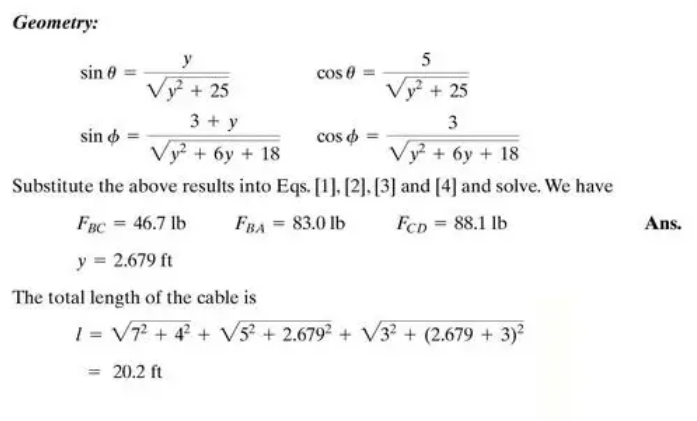

####Exercício 2:

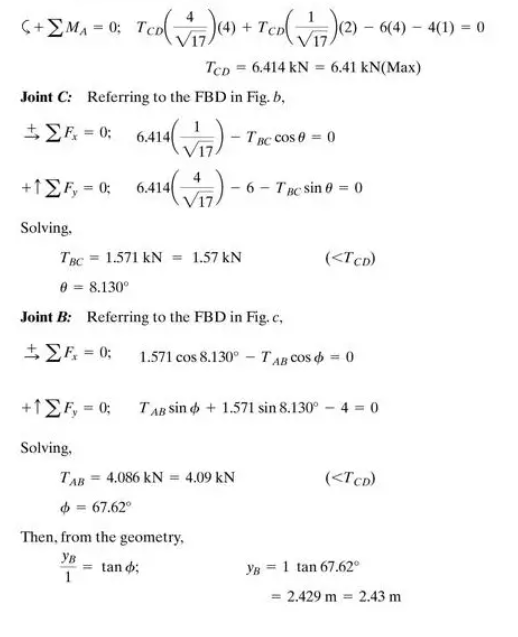

####Exercício 3

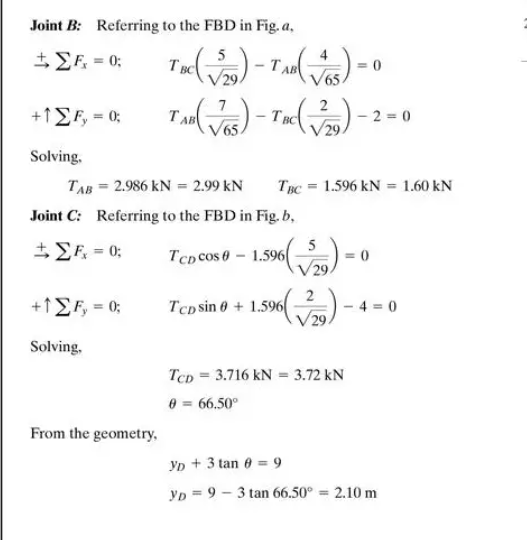

# Questão 2:
Considere um cabo flexı́vel, suspenso por dois apoios de segundo gênero nos pontos A e B, sujeito
a um carregamento uniformemente distribuı́do (vertical e para baixo) de intensidade w0. Admita que o
cabo apresenta formato parabólico, descrito por

$$y(x) = a x^2 + bx + c$$

Seja C o ponto mais baixo do cabo deformado, adotado como origem do sistema de eixos, isto é,
C = (0, 0). As alturas dos apoios A e B são conhecidas (yA e yB ), assim como a distância horizontal
entre eles, L. No entanto, as abscissas xA e xB não são conhecidas a priori.

(a) Identifique um conjunto de quatro equações que permita determinar as incógnitas do problema.

(b) Utilize um esquema simbólico para resolver o sistema de equações obtido. Siga a estrutura abaixo:

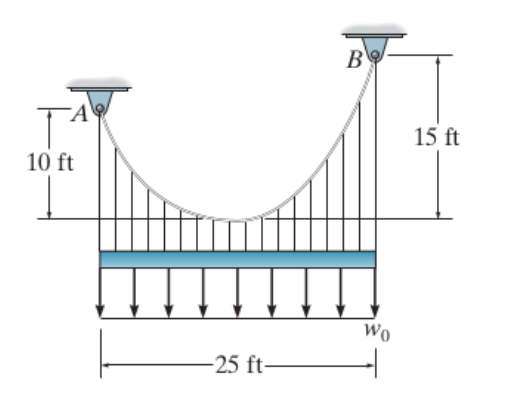

## Letra A

Considerando a distribuição no eixo cartesiano, é possível perceber que o valor de L pode ser calculado como:

$$ L = x_B - x_A$$

A equação tem forma parabólica no tipo

$$ y(x) = a\cdot x² + b\cdot x+c$$

orientando o eixo cartesiano com o ponto C nas coordenadas C=(0,0), sabemos que pela expressão de y a variável c deve ser igual a 0

$$ y(x_c) = y(0) = 0 =  a\cdot 0² + b\cdot 0+c$$
$$ c = 0$$

e a expressão de y fica como:
$$ y(x) = a\cdot x² + b\cdot x$$

no entanto considerando que a expressão descreve uma parábola, sabemos que a derivada em seu ponto de máximo ou mínimo deve ser igual a 0, considerando pela distribuição da parábola
que esse ponto deve estar localizado em C temos:

$$ y'(x) = 2a\cdot x + b$$
$$ y'(x_c) = y'(0) = 0 = 2a\cdot 0 + b$$
$$ b = 0$$

a expressão de y então termina como

$$ y(x) = a \cdot x²$$


considerando que a expressão de y para um cabo flexível que sustenta um carregamento uniforme $w_0$ é dada por:

$$ y(x) = \frac{w_0}{2F_h}\cdot x²$$

com isso:
$$ y(x_A) = 10$$
$$ y(x_B) = 15$$

é possível combinar essas expressões e encontrar:

$$ y(x_A) = 10 = \frac{w_0}{2F_h}\cdot x_A² => x_A² = 20\frac{F_h}{w_0}$$
$$ y(x_B) = 15 = \frac{w_0}{2F_h}\cdot x_B² => x_B² = 30\frac{F_h}{w_0}$$

substituindo os valores de $x_A$ ou $x_B$ encontrados na primeira expressão encontra-se:

$$ y(x_A) = 10 = a \cdot 20 \frac{F_h}{w_0} => F_h = \frac{w_0}{2a} $$
$$ y(x_B) = 15 = a \cdot 30 \frac{F_h}{w_0} => F_h = \frac{w_0}{2a} $$


### Equações
As 4 equações são:
1. $ y(x_A) = a \cdot x_A^2$
2. $ y(x_B) = a \cdot x_B^2$
3. $ L= |x_B| - |x_A|$
4. $ F_h = \frac{w_0}{2a}$



## Letra B

Solução do exercício no modelo do código fornecido pelo enunciado

In [ ]:
import sympy as sp

w0_val = 600
yA_val = 10.0
yB_val = 15.0
L_val  = 25.0

# expressões simbólicas
w0, yA, yB, L = sp.symbols('w0 yA yB L')
xA, xB, a, Fh = sp.symbols('xA xB a Fh')

#equações do problema definidas na letra A
eq1 = sp.Eq(a*xA**2, yA)
eq2 = sp.Eq(a*xB**2, yB)
eq3 = sp.Eq(xB - xA, L)
eq4 = sp.Eq(a, w0/(2*Fh))

sol = sp.solve([eq1, eq2, eq3, eq4], [xA, xB, a, Fh], dict=True)

subs = {w0: w0_val, yA: yA_val, yB: yB_val, L: L_val}
#vetor de substituições [{xA: eq1.subs(xA,yA),...}]
sol_sub = [ {k: v.subs(subs) for k,v in s.items()} for s in sol ]

print(f"As soluções simbólicas para o sistema são:")
for i in sol:
    print(i)

print(f"\nO conjunto de todas as soluções para o sistema é:")
for i in sol_sub:
    print(i)


As soluções simbólicas para o sistema são:
{Fh: L**2*w0*(yA + yB - 2*sqrt(yA*yB))/(2*(yA**2 - 2*yA*yB + yB**2)), a: (yA + yB + 2*sqrt(yA*yB))/L**2, xA: L*(-yA + sqrt(yA*yB))/(yA - yB), xB: L*(-yB + sqrt(yA*yB))/(yA - yB)}
{Fh: L**2*w0*(yA + yB + 2*sqrt(yA*yB))/(2*(yA**2 - 2*yA*yB + yB**2)), a: (yA + yB - 2*sqrt(yA*yB))/L**2, xA: -L*(yA + sqrt(yA*yB))/(yA - yB), xB: -L*(yB + sqrt(yA*yB))/(yA - yB)}

O conjunto de todas as soluções para o sistema é:
{Fh: 3788.26929126162, a: 0.0791918358845309, xA: -11.2372435695795, xB: 13.7627564304205}
{Fh: 371211.730708738, a: 0.000808164115469141, xA: 111.237243569579, xB: 136.237243569579}


## Letra C

É feito o filtro sobre o resultado da questão anterior, que pega apenas a reposta do método sp.solve() usado onde C=(0,0) e $x_A < 0$ e $x_B > 0$

In [ ]:
valido = []
for s in sol_sub:
    s_eval = {k: v for k,v in s.items()}
    if all(v.is_real for v in s_eval.values()):
        #filtra o resultado onde C=(0,0) de acordo com os valores medidos para xA e xB, xA < 0 , xB>0
        if float(s_eval[xA]) < 0 and float(s_eval[xB]) > 0:
            valido.append({k: float(v) for k,v in s_eval.items()})

print(valido)

[{Fh: 3788.269291261619, a: 0.07919183588453085, xA: -11.23724356957946, xB: 13.76275643042054}]


## Letra D

Cálculo das Reações de apoio considerando os valores de xA,yA,xB,yB e FH com carregamento uniforme $w_0 = 600$

Utilizando as relações das expressões de cabos:

$$ \frac{dy}{dx} = \tan \theta = \frac{w_0}{F_h} \cdot x$$
$$ T = \frac{F_h}{\cos (\theta _a)} $$

é possível calcular as tensões:

$$ \tan \theta _a = \frac{600}{3788.2692} \cdot -11.2372 \approx -1.7797$$
$$ \theta _a = -60,67°$$

$$T_a = 7,73 kN$$

$$ \tan \theta _b = \frac{600}{3788.2692} \cdot 13.7627 \approx 2.1797$$
$$ \theta _b = 65.35°$$

$$T_b = 9.08 kN$$

Utiizando o método dos nós:

Nó A:
  $$ \sum F_x = H_a + T_{ax} = 0 => H_a = -F_h = -3788.2692$$
  $$ \sum F_y = V_a - T_{ay} = 0 => H_a = T_{ay} = T_a * \sin (-60.67) = -6.7391 kN$$
Nó B:
  $$ \sum F_x = H_b - T_{bx} = 0 => H_b = F_h = 3788.2692$$
  $$ \sum F_y = V_b - T_{by} = 0 => H_b = T_{by} = T_b * \sin (65.35) = 8.2525 kN$$

# Questão 3

## Letra A

Deslocamentos e reações da estrutura

(Elemento: AB, EA:210000000000.0)
(Elemento: AH, EA:210000000000.0)
(Elemento: AE, EA:210000000000.0)
(Elemento: BH, EA:210000000000.0)
(Elemento: BC, EA:210000000000.0)
(Elemento: HC, EA:210000000000.0)
(Elemento: HG, EA:210000000000.0)
(Elemento: CG, EA:210000000000.0)
(Elemento: CF, EA:210000000000.0)
(Elemento: CD, EA:210000000000.0)
(Elemento: GF, EA:210000000000.0)
(Elemento: FD, EA:210000000000.0)
(Elemento: FE, EA:210000000000.0)
(Elemento: DE, EA:210000000000.0)
Estrutura modelada:


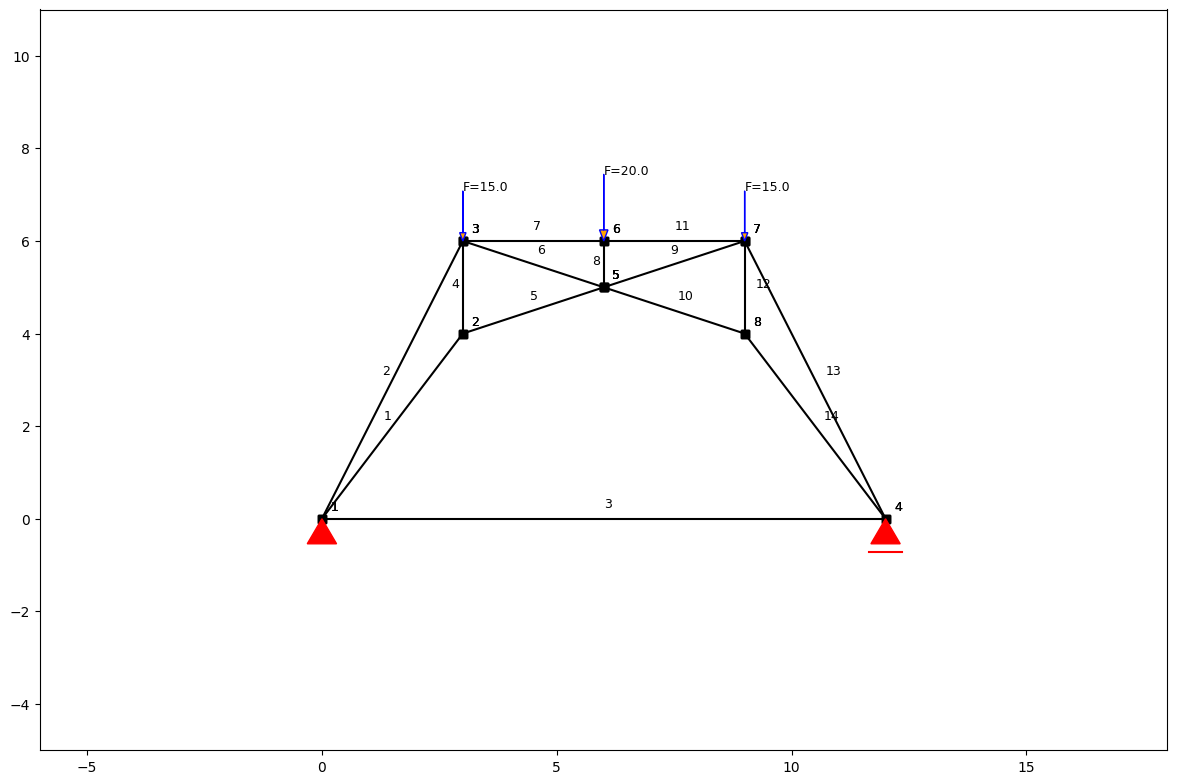

Plots Estrutura:
Reação de apoios:


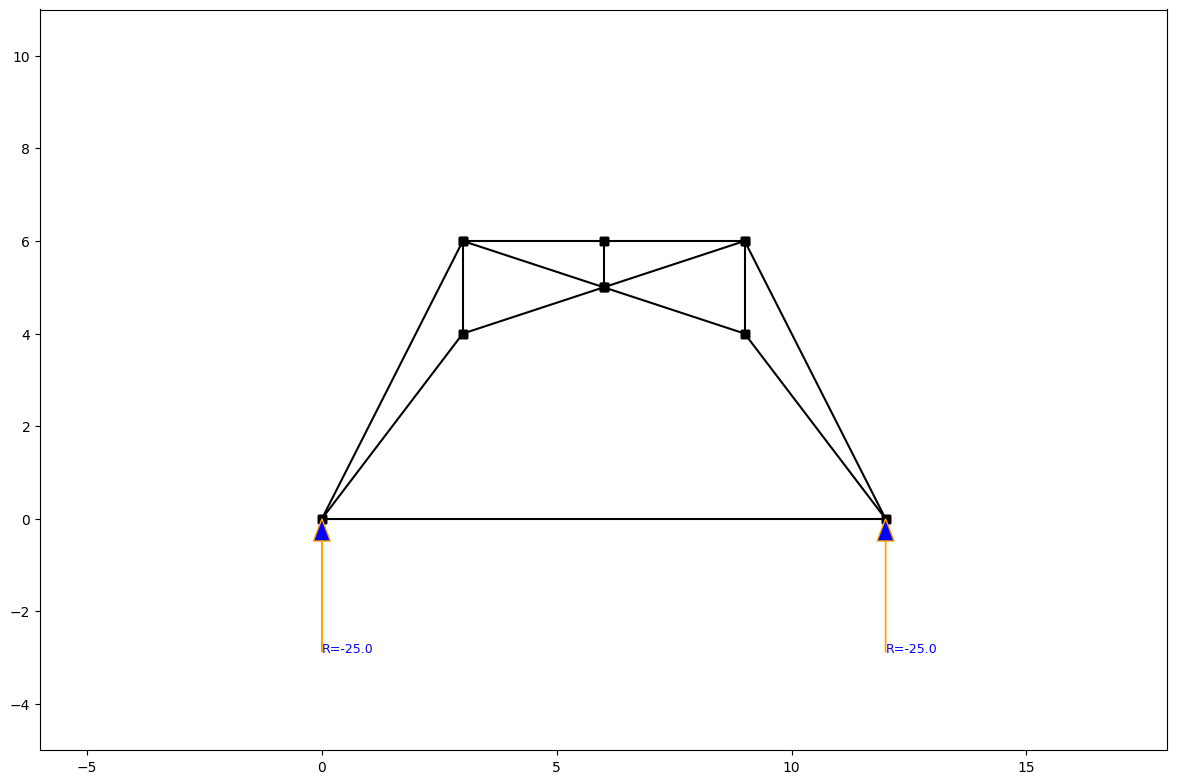

Reação axial:


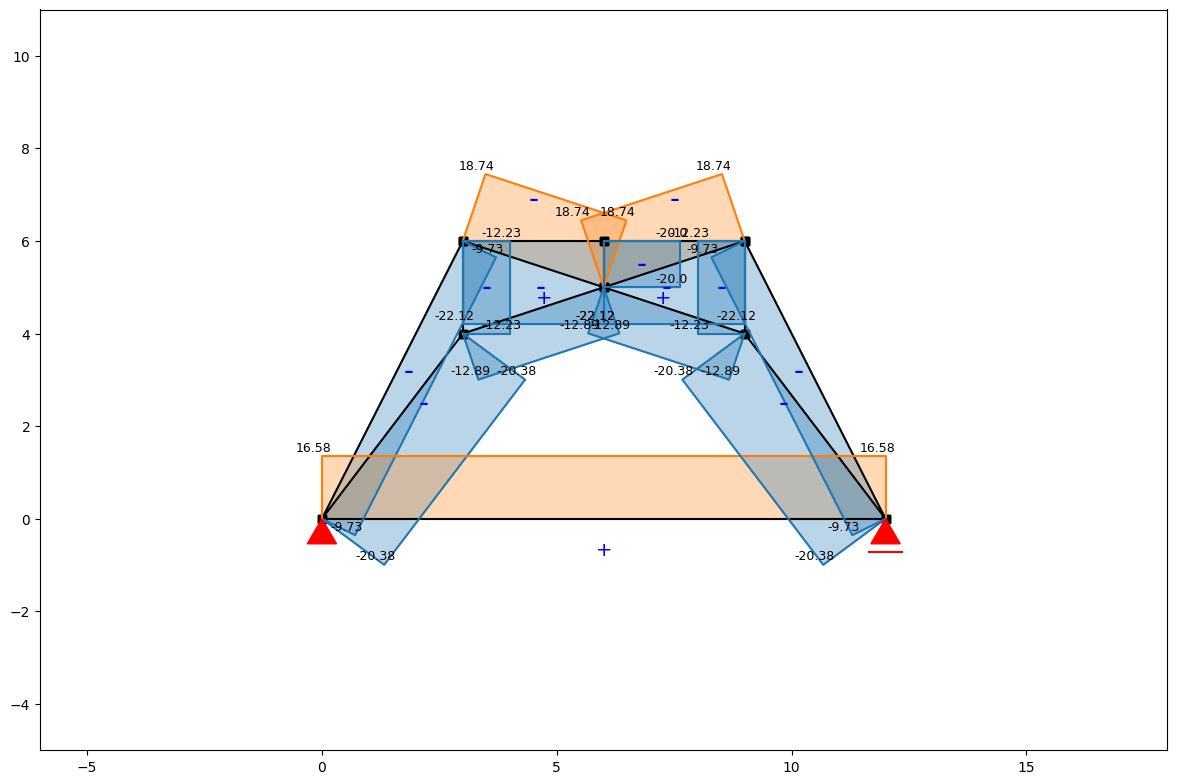

Deslocamentos:


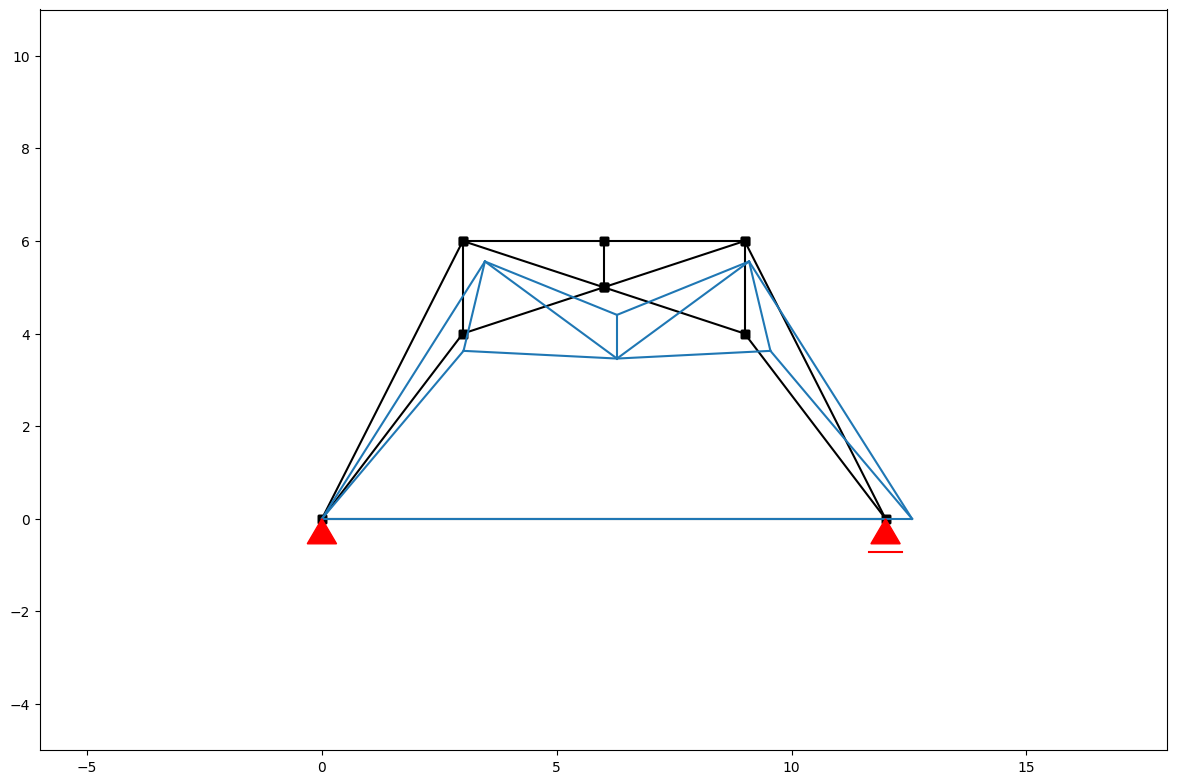


Deslocamentos por nó (mm):
Nó A: ux = 0.0000 mm | uy = -0.0000 mm
Nó B: ux = 0.0001 mm | uy = -0.0020 mm
Nó H: ux = 0.0025 mm | uy = -0.0024 mm
Nó C: ux = 0.0015 mm | uy = -0.0082 mm
Nó G: ux = 0.0015 mm | uy = -0.0085 mm
Nó F: ux = 0.0005 mm | uy = -0.0024 mm
Nó D: ux = 0.0029 mm | uy = -0.0020 mm
Nó E: ux = 0.0030 mm | uy = -0.0000 mm

Esforços nas barras:
Barra AB: 20.38 N (Compressão)
Barra AH: 9.73 N (Compressão)
Barra AE: 16.58 N (Tração)
Barra BH: 12.23 N (Compressão)
Barra BC: 12.89 N (Compressão)
Barra HC: 18.74 N (Tração)
Barra HG: 22.12 N (Compressão)
Barra CG: 20.00 N (Compressão)
Barra CF: 18.74 N (Tração)
Barra CD: 12.89 N (Compressão)
Barra GF: 22.12 N (Compressão)
Barra FD: 12.23 N (Compressão)
Barra FE: 9.73 N (Compressão)
Barra DE: 20.38 N (Compressão)


In [ ]:
#LINK PLANILHA: https://docs.google.com/spreadsheets/d/1WLxaC4IPEMtw8W_O78WW9-GWAgiHwTq-VKR1SYW5bvo/edit?usp=sharing

Est03_A = Estrutura(sheet_id="https://docs.google.com/spreadsheets/d/1WLxaC4IPEMtw8W_O78WW9-GWAgiHwTq-VKR1SYW5bvo/edit?usp=sharing")
Est03_A.solve_sys()

## Letra B

Recalculando sem as barras FG e GH

(Elemento: AB, EA:210000000000.0)
(Elemento: AH, EA:210000000000.0)
(Elemento: AE, EA:210000000000.0)
(Elemento: BH, EA:210000000000.0)
(Elemento: BC, EA:210000000000.0)
(Elemento: HC, EA:210000000000.0)
(Elemento: CG, EA:210000000000.0)
(Elemento: CF, EA:210000000000.0)
(Elemento: CD, EA:210000000000.0)
(Elemento: FD, EA:210000000000.0)
(Elemento: FE, EA:210000000000.0)
(Elemento: DE, EA:210000000000.0)
Estrutura modelada:


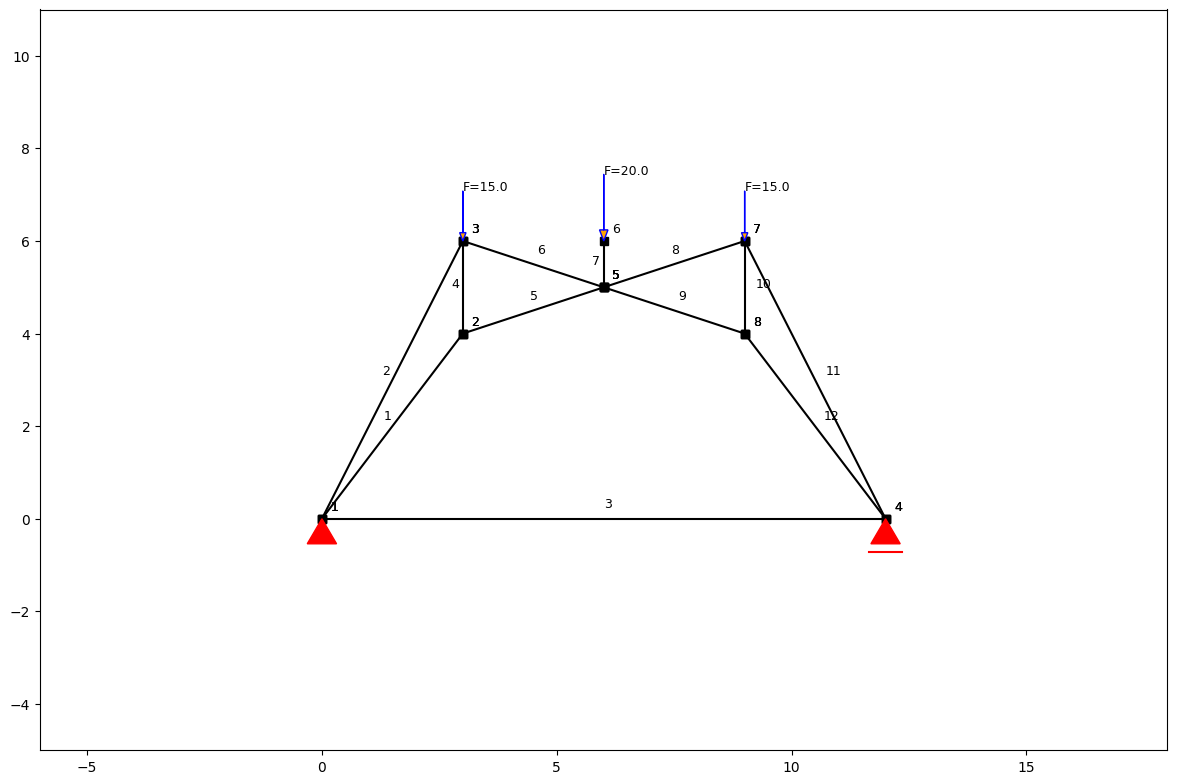

Plots Estrutura:
Reação de apoios:


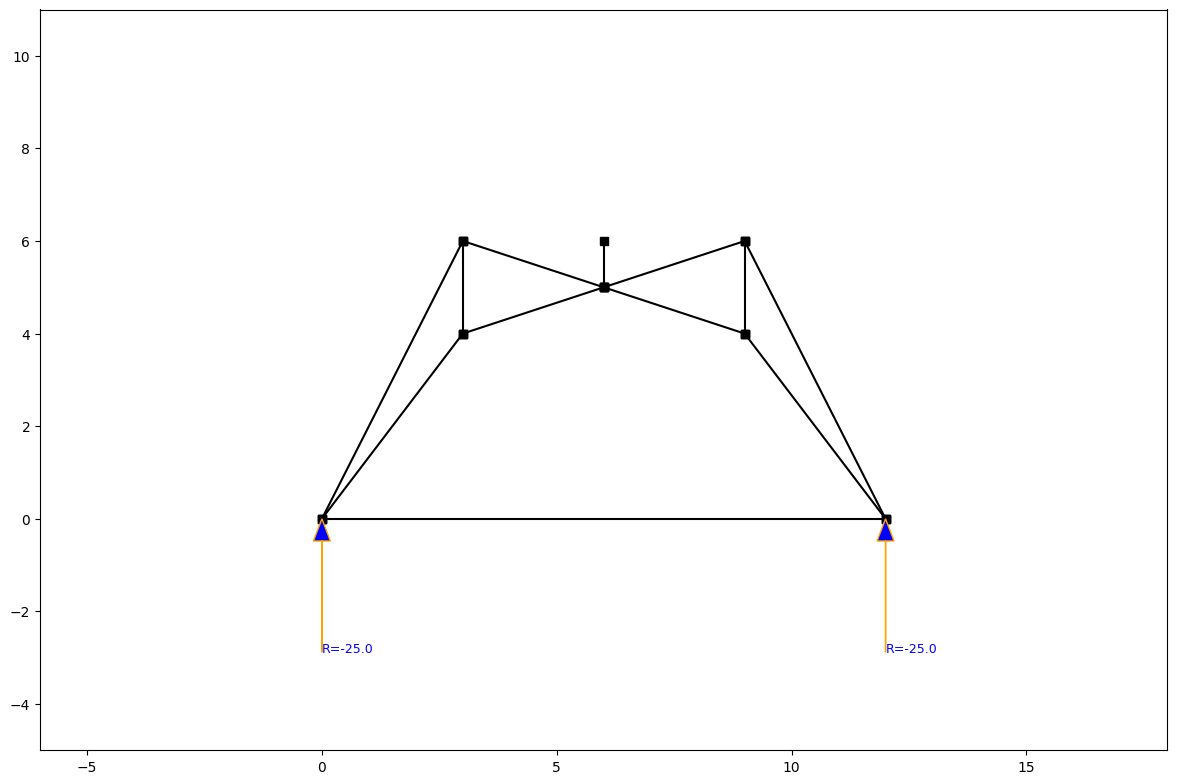

Reação axial:


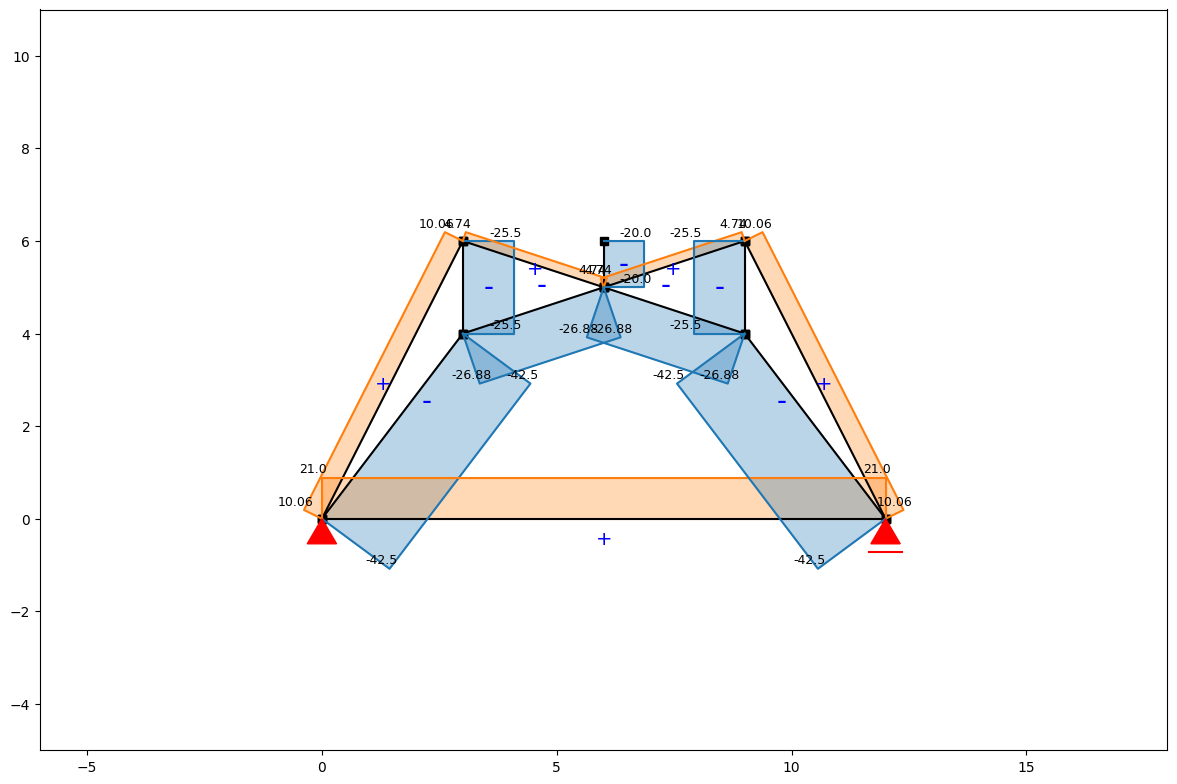

Deslocamentos:


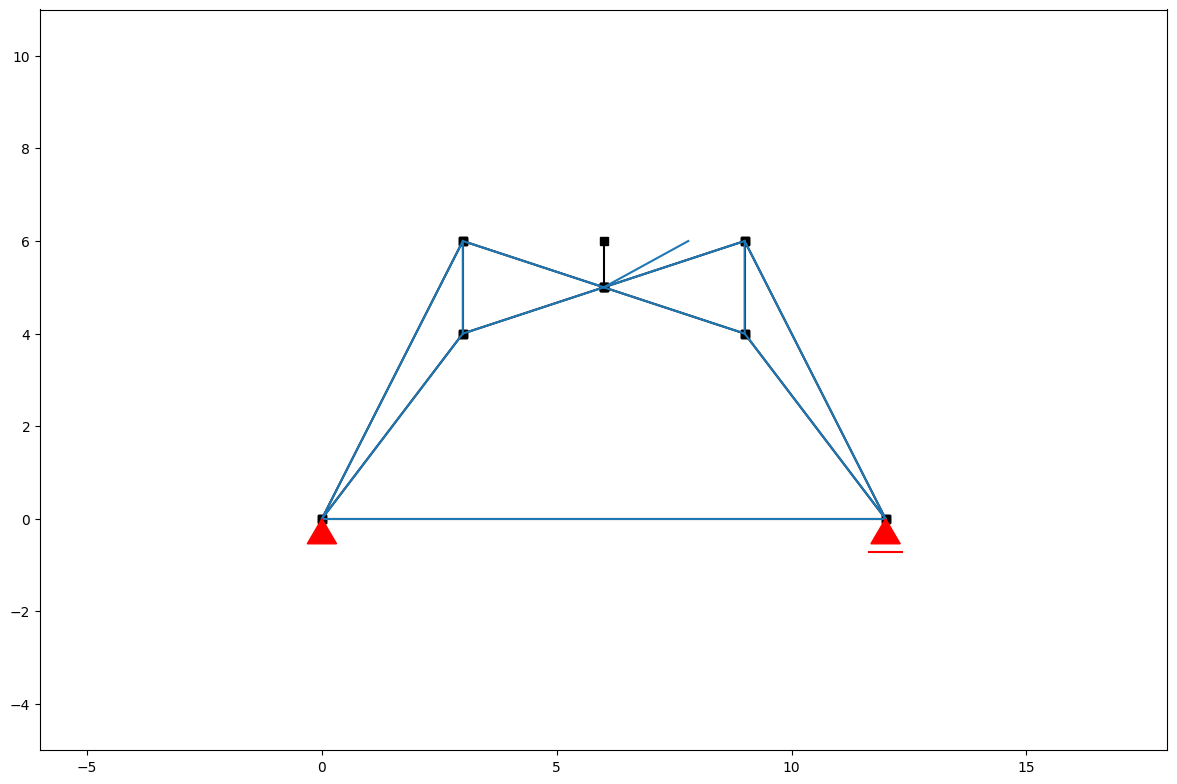


Deslocamentos por nó (mm):
Nó A: ux = 0.0000 mm | uy = -0.0000 mm
Nó B: ux = -0.0029 mm | uy = -0.0019 mm
Nó H: ux = 0.0076 mm | uy = -0.0026 mm
Nó C: ux = 0.0019 mm | uy = -0.0203 mm
Nó G: ux = 66.6577 mm | uy = -0.0206 mm
Nó F: ux = -0.0037 mm | uy = -0.0026 mm
Nó D: ux = 0.0067 mm | uy = -0.0019 mm
Nó E: ux = 0.0038 mm | uy = -0.0000 mm

Esforços nas barras:
Barra AB: 42.50 N (Compressão)
Barra AH: 10.06 N (Tração)
Barra AE: 21.00 N (Tração)
Barra BH: 25.50 N (Compressão)
Barra BC: 26.88 N (Compressão)
Barra HC: 4.74 N (Tração)
Barra CG: 20.00 N (Compressão)
Barra CF: 4.74 N (Tração)
Barra CD: 26.88 N (Compressão)
Barra FD: 25.50 N (Compressão)
Barra FE: 10.06 N (Tração)
Barra DE: 42.50 N (Compressão)


In [ ]:
Est03_B = Estrutura(sheet_id="https://docs.google.com/spreadsheets/d/1zRZ5DuFTrTcjFpESzoBjM9rYxey8PtuqLwtJFHJMxx4/edit?usp=sharing")
Est03_B.solve_sys()

## Letra C

Recalculando mas simulando as barras FG, GH com EA nulo


(Elemento: AB, EA:100000.0)
(Elemento: AH, EA:100000.0)
(Elemento: AE, EA:100000.0)
(Elemento: BH, EA:100000.0)
(Elemento: BC, EA:100000.0)
(Elemento: HC, EA:100000.0)
(Elemento: HG, EA:1000)
(Elemento: CG, EA:100000.0)
(Elemento: CF, EA:100000.0)
(Elemento: CD, EA:100000.0)
(Elemento: GF, EA:1000)
(Elemento: FD, EA:100000.0)
(Elemento: FE, EA:100000.0)
(Elemento: DE, EA:100000.0)
Estrutura modelada:


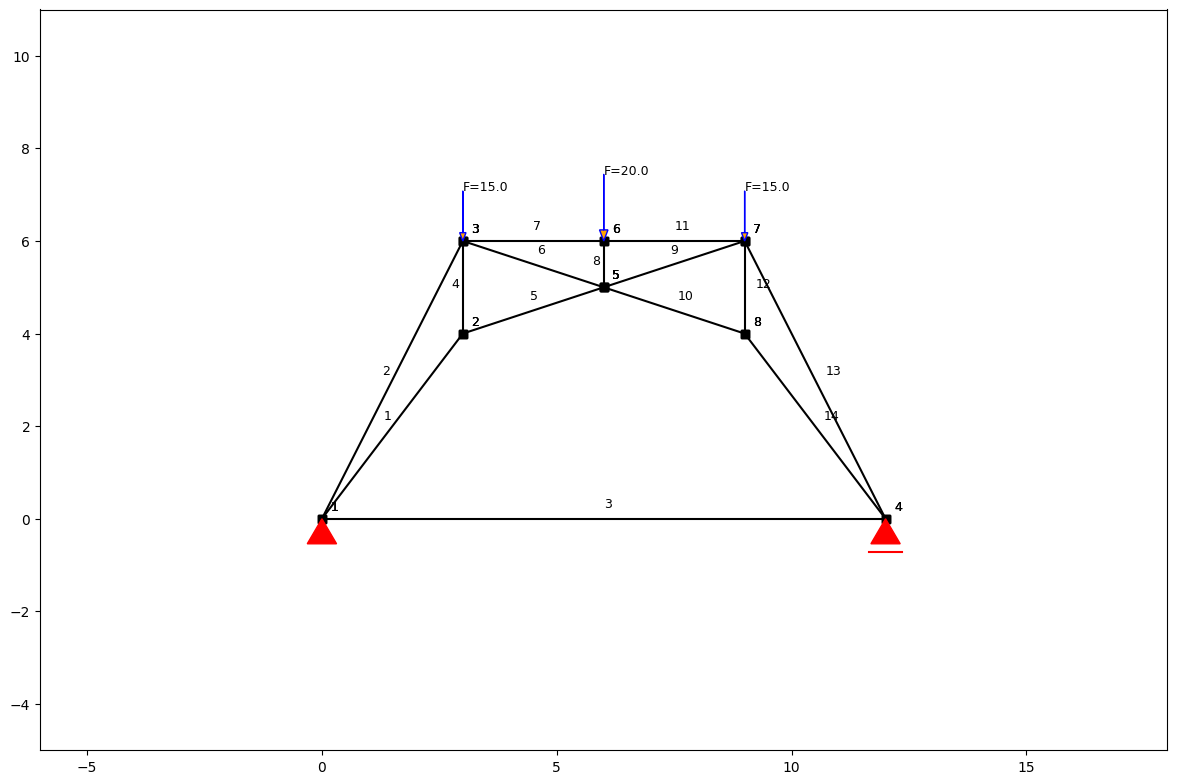

Plots Estrutura:
Reação de apoios:


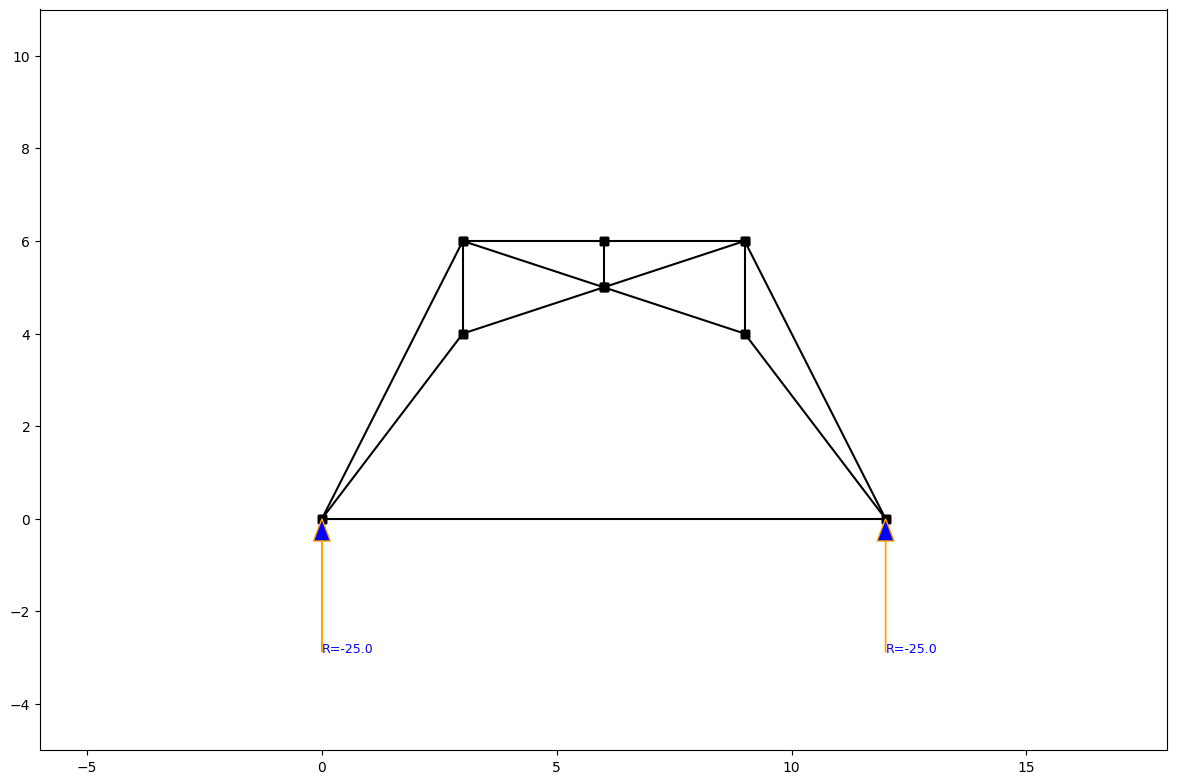

Reação axial:


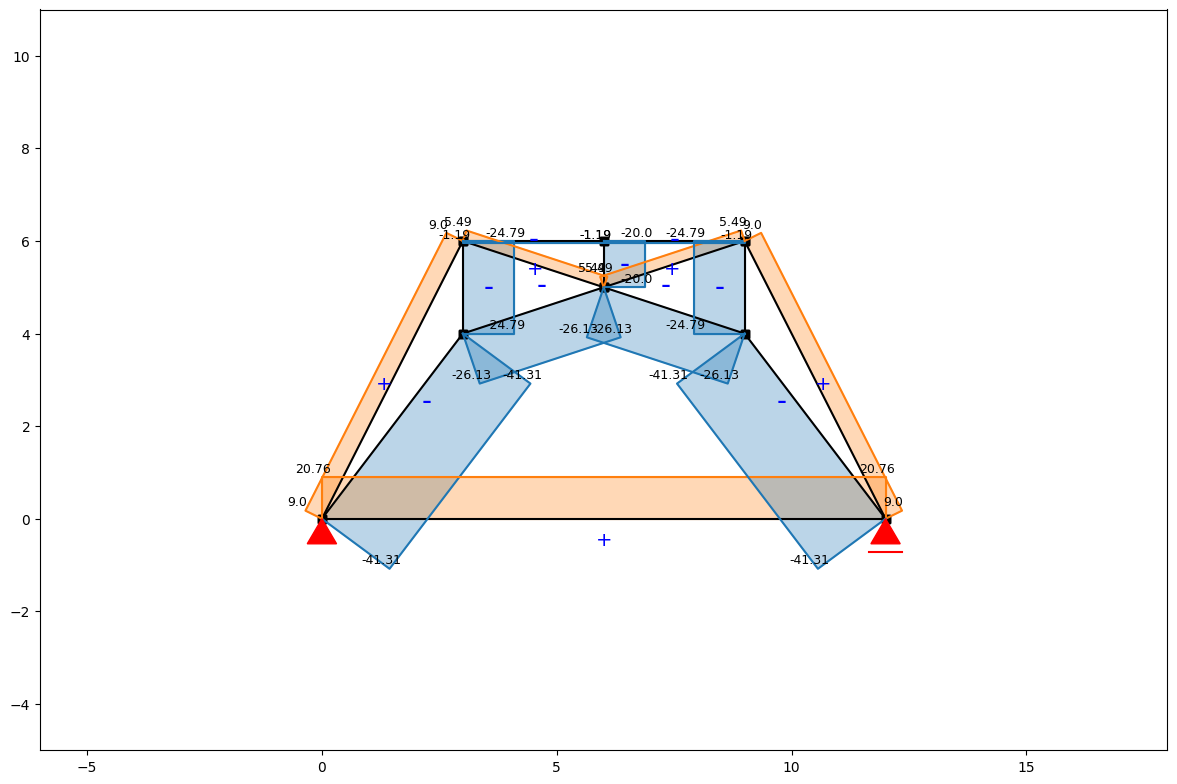

Deslocamentos:


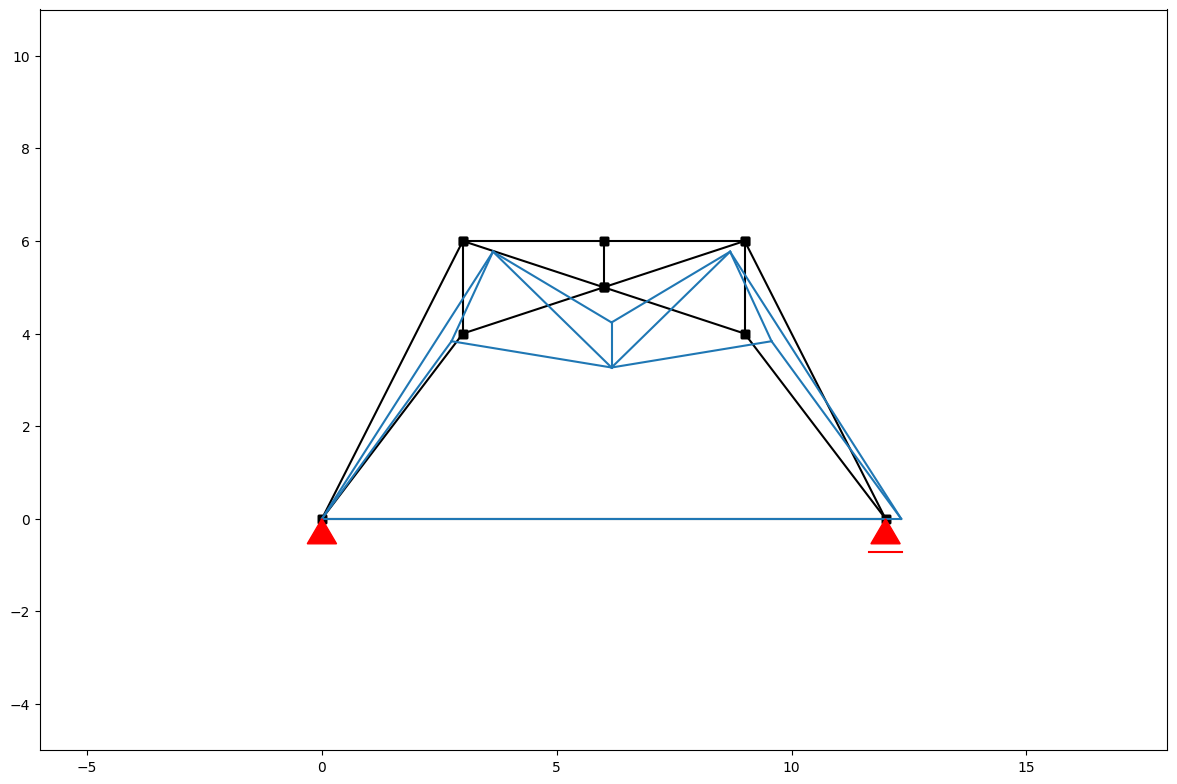


Deslocamentos por nó (mm):
Nó A: ux = 0.0000 mm | uy = -0.0000 mm
Nó B: ux = -5718.5940 mm | uy = -3929.7623 mm
Nó H: ux = 15312.4464 mm | uy = -5507.7542 mm
Nó C: ux = 3965.3160 mm | uy = -41298.2401 mm
Nó G: ux = 3965.3160 mm | uy = -41934.8599 mm
Nó F: ux = -7381.8143 mm | uy = -5507.7542 mm
Nó D: ux = 13649.2261 mm | uy = -3929.7623 mm
Nó E: ux = 7930.6321 mm | uy = -0.0000 mm

Esforços nas barras:
Barra AB: 41.31 N (Compressão)
Barra AH: 9.00 N (Tração)
Barra AE: 20.76 N (Tração)
Barra BH: 24.79 N (Compressão)
Barra BC: 26.13 N (Compressão)
Barra HC: 5.49 N (Tração)
Barra HG: 1.19 N (Compressão)
Barra CG: 20.00 N (Compressão)
Barra CF: 5.49 N (Tração)
Barra CD: 26.13 N (Compressão)
Barra GF: 1.19 N (Compressão)
Barra FD: 24.79 N (Compressão)
Barra FE: 9.00 N (Tração)
Barra DE: 41.31 N (Compressão)


In [ ]:
Est03_C = Estrutura(sheet_id="https://docs.google.com/spreadsheets/d/12W51L6wPiFjaXBWzlMD36jXCSn4qLPKslaJ7MAD_mUo/edit?usp=sharing",E=1e5)
Est03_C.solve_sys()